In [1]:
import numpy as np
import xarray as xr
import pyart
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.ticker import MultipleLocator
from matplotlib.patches import Circle
import glob
import sys
import os
from grf_functions import *

plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['text.latex.preamble'] = r'\usepackage{bm}'
rc('font', family='sans-serif')
rc('font', weight='normal', size=12)
rc('figure', facecolor='white')
rc('axes', titlesize=15)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [4]:
# project directory
dproj = "/data/arrcwx/wrt_jtrf/"
# case (morton or arnett)
case = "morton"
# full path to IQ file
drkc = f"{dproj}{case}/iq/RAXPOL-20250605-223917.911.rkc"
# desired azimuthal resolution (degrees)
des_az = 0.50

In [5]:
# read in rkc file
rkid = rkcfile(drkc, verbose=False)

# file string
file = os.path.basename(drkc)

'RAXPOL-20250605-223917.911.rkc'

In [6]:
# file string
file = os.path.basename(drkc)
tstring = file[7:-8]
tplot = datetime.strptime(tstring, "%Y%m%d-%H%M%S")

In [8]:
# iq
pulses = rkid.pulses['iq'] # shape (pulse,iq,gate,hv)
# reshape
pulses = pulses.transpose((1,2,3,0)) # shape (iq,gate,hv,pulse)
# combine signals
pulses = pulses[0,:,:,:] + 1.j*pulses[1,:,:,:] # shape (gate,hv,pulse)
# reshape again
pulses = pulses.transpose((0,2,1)).astype(np.complex128) # shape (gate, pulse, hv)

# wavelength
lamb = rkid.header['desc']['wavelength']
# pulse repitition time
prt = rkid.header['config']['prt']
# lore accurate speed of light
c = 299,792,458
# sample
sample_freq = int(rkid.header['waveform']['fs'])
sample_time = 1/sample_freq
# nyquist velocity
va = lamb/(4*prt)

# number of pulses
npulse = pulses.shape[1]
# rays per sweeps
nray = int(360/des_az)
# number of range gates
ngate = pulses.shape[0]
# pulses per ray
ppr = npulse // nray
# total number of pulses
n = nray * ppr

# azimuths
az = rkid.pulses['azimuthDegrees']
# elevation angle
el = rkid.pulses['elevationDegrees']

# horizontal iq
Xh = pulses[:,:n,0] # shape (gate, pulse)
Xh = np.reshape(Xh, (ngate, nray, ppr)) # shape (gate, ray, pulse)
# vertical iq
Xv = pulses[:,:n,1]
Xv = np.reshape(Xv, (ngate, nray, ppr)) # shape (gate, ray, pulse)

# reshape azimuths
az = np.reshape(az[:n], (nray, ppr))
az = az[:,0]
# reshape elevations
el = np.reshape(el[:n], (nray, ppr))
el = np.nanmean(el, axis=1)
# set range array
if rkid.header['buildNo'] >= 4:
    if rkid.header['dataType'] == 'raw':
        dr = rkid.header['config']['pulseGateSize']
        # dt = dr * 2 / (c/1e6)
    elif rkid.header['dataType'] == 'compressed':
        dr = rkid.header['desc']['pulseToRayRatio'] * rkid.header['config']['pulseGateSize']
        # dt = dr * 2 / (c/1e6)
    else:
        print("Inconsistency detected. This should not happen.")
        dr = 30.
r = np.arange(0, ngate) * dr

# cartesian positions
x = r[:,np.newaxis].dot(np.sin(np.deg2rad(az[np.newaxis,:]))).T
y = r[:,np.newaxis].dot(np.cos(np.deg2rad(az[np.newaxis,:]))).T

In [9]:
# partially cluttered gate location
xc, yc = 3.21*1e3, 4.70*1e3
# find r, az indices
rc = np.sqrt(xc**2 + yc**2)
rc_idx = np.argmin(np.abs(r-rc))
azc = np.rad2deg(np.arctan2(xc,yc)) % 360
azc_idx = np.argmin(np.abs(az-azc))
# clutter gate signal
Xhc = Xh[rc_idx, azc_idx, :]

# weather signal gate location
xw, yw = 3.5*1e3, 4.70*1e3
# find r, az indices
rw = np.sqrt(xw**2 + yw**2)
rw_idx = np.argmin(np.abs(r-rw))
azw = np.rad2deg(np.arctan2(xw,yw)) % 360
azw_idx = np.argmin(np.abs(az-azw))
# clutter gate signal
Xhw = Xh[rw_idx, azw_idx, :]

In [18]:
nfft = ppr*1
# clutter PSD
PSDc = np.abs(np.fft.fft(Xhc, n=nfft))**2
PSDc = 10 * np.log10(PSDc*(prt/Xhc.size))
PSDc = np.fft.fftshift(PSDc)
# weather PSD
PSDw = np.abs(np.fft.fft(Xhw, n=nfft))**2
PSDw = 10 * np.log10(PSDw*(prt/Xhw.size))
PSDw = np.fft.fftshift(PSDw)

# Doppler frequency
f = np.fft.fftfreq(nfft)
fd = f / prt
fd = np.fft.fftshift(fd)
# radial velocity
Vr = (fd * 0.03) / 2

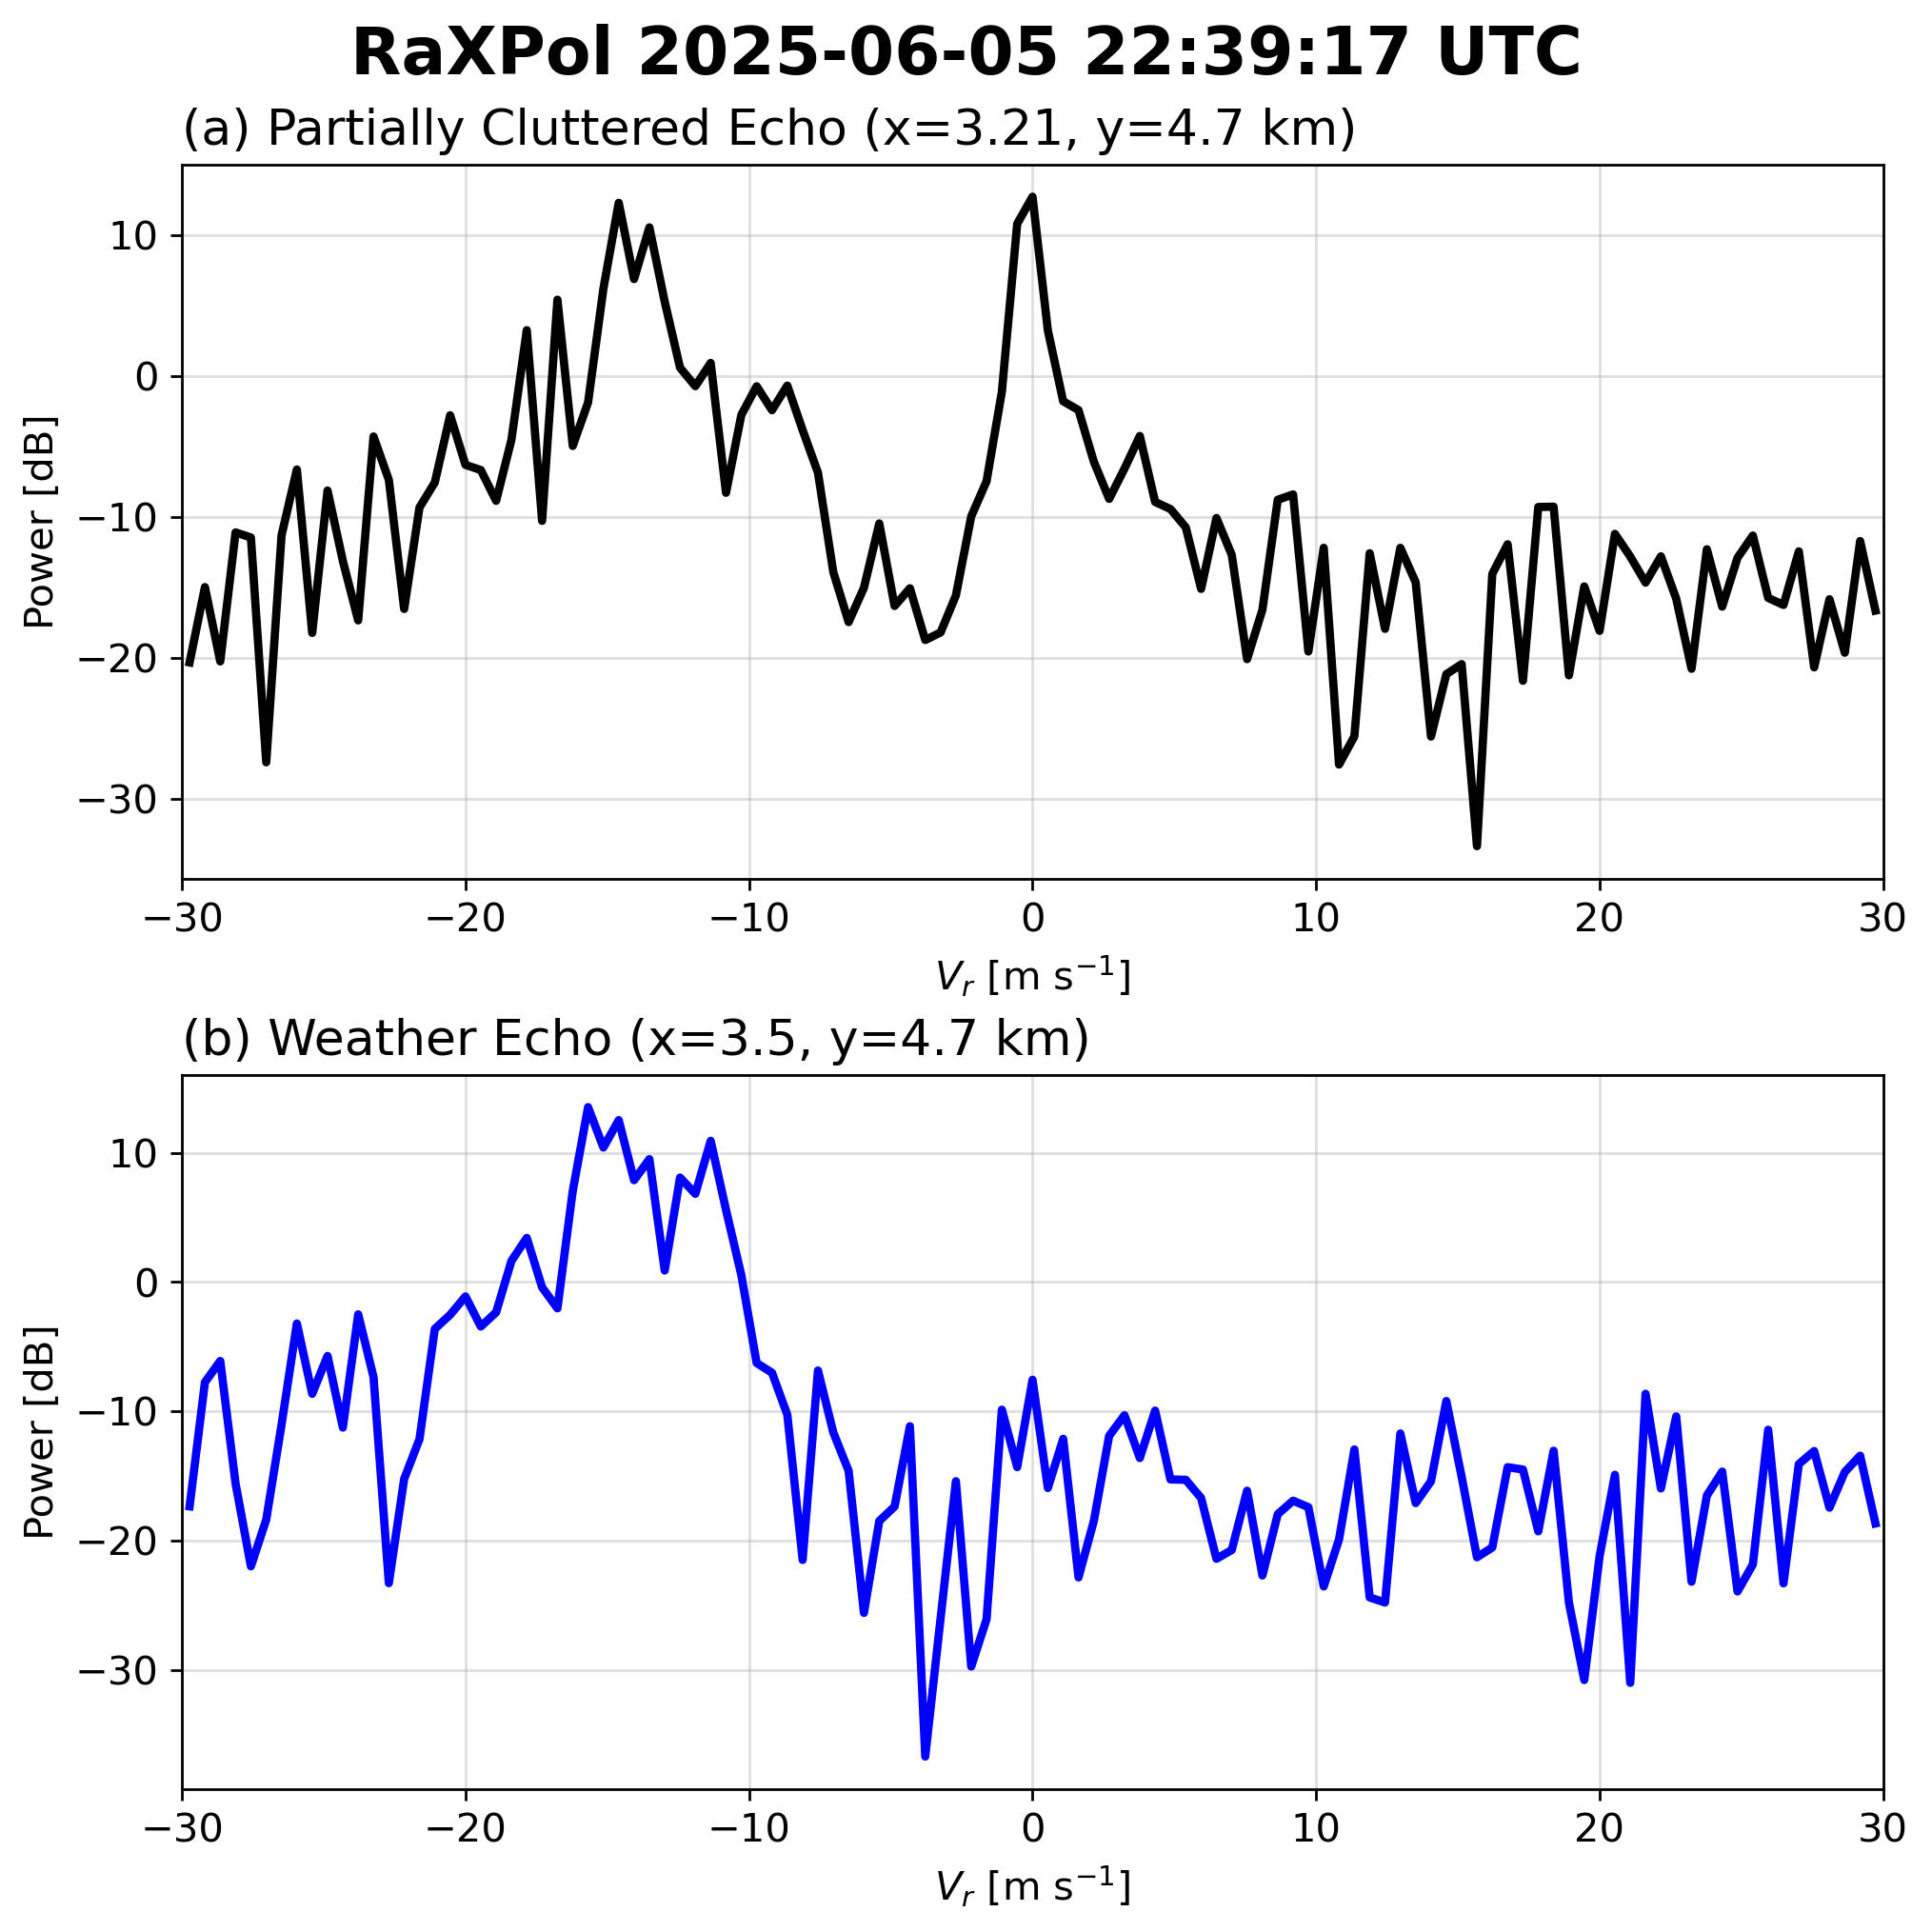

In [19]:
fig, axs = plt.subplots(figsize=(8,8),
                       constrained_layout=True,
                       dpi=250,
                       nrows=2,
                       ncols=1)
fig.suptitle(f"RaXPol {tplot} UTC", fontweight='bold', fontsize=20)

# clutter echo
ax = axs[0]
ax.plot(Vr, PSDc, lw=2.5, c='black')
ax.set_title(f"(a) Partially Cluttered Echo (x={xc/1e3}, y={yc/1e3} km)", loc='left')
# weather echo
ax = axs[1]
ax.plot(Vr, PSDw, lw=2.5, c='blue')
ax.set_title(f"(b) Weather Echo (x={xw/1e3}, y={yw/1e3} km)", loc='left')

# clean up
for ax in axs:
    ax.set_xlabel("$V_r$ [m s$^{-1}$]")
    ax.set_ylabel("Power [dB]")
    ax.set_xlim(-30,30)
    ax.grid(alpha=0.4)